# Домашнее задание 2. CycleGAN

## Загрузка данных


>Решением домашки является архив с использованными тетрадками/модулями. Необходимо объяснять каждый пункт решения. В нем необходимо описать какие эксперименты вы производили для полученного результата, а так же обосновать почему вы решили использовать те или иные вариации и хаки для ганов - например, дополнительные лоссы для стабилизации и т.п.

In [2]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

0

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.utils as vutils
from tqdm.auto import tqdm

## prepare data

In [ ]:
# !git clone https://github.com/Lornatang/CycleGAN-PyTorch #download-dataset
# %cd ./#download-dataset

In [ ]:
# !pip install -r requirements.txt
# !pip install munch

In [ ]:
# import requests, zipfile
# from io import BytesIO

# download_link = "https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip"


# %cd /content/CycleGAN-PyTorch/data
# r = requests.get(download_link, stream=True)
# z = zipfile.ZipFile(BytesIO(r.content))
# z.extractall()

# %cd /content/CycleGAN-PyTorch

In [ ]:
# %cd /content/CycleGAN-PyTorch

In [4]:
import os
os.chdir(r"e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan")
print(os.getcwd())


e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan


In [ ]:
import argparse
import itertools
import random

import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
from tqdm.auto import tqdm

#%run ./#cyclegan/dataset.py
#%run ./#cyclegan/imgproc.py
#%run ./#cyclegan/model.py
#%run ./#cyclegan/utils.py

%run dataset.py
%run imgproc.py
%run model.py
%run utils.py

from munch import Munch


In [6]:
args = Munch()
# args.dataroot = "./data"
args.dataroot = r"e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\horse2zebra"  
args.dataset = ""
args.testA="testA"
args.testB="testB"
args.trainA="trainA"
args.trainB="trainB"
args.batch_size=16
args.cuda=True
args.image_size=286
args.manualSeed=1

if args.manualSeed is None:
    args.manualSeed = random.randint(1, 10000)
random.seed(args.manualSeed)
torch.manual_seed(args.manualSeed)

In [6]:
src_path = os.path.join(args.dataroot, args.trainA)
dst_path = os.path.join(args.dataroot, args.trainB)
print("Absolute path for trainA:", os.path.abspath(src_path))
print("Absolute path for trainB:", os.path.abspath(dst_path))


Absolute path for trainA: e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\horse2zebra\trainA
Absolute path for trainB: e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\horse2zebra\trainB


## Creating a Dataset and a Dataloader

In [7]:
cudnn.benchmark = True

if torch.cuda.is_available() and not args.cuda:
    print("WARNING: You have a CUDA device, so you should probably run with --cuda")

# Dataset
dataset = ImageDataset(src_images_dir=os.path.join(args.dataroot, args.dataset, args.trainA),
                       dst_images_dir=os.path.join(args.dataroot, args.dataset, args.trainB),
                       resized_image_size=int(args.image_size * 1.12),
                       unpaired=True,
                       )

dataloader = torch.utils.data.DataLoader(dataset, batch_size=args.batch_size, shuffle=True, pin_memory=True)

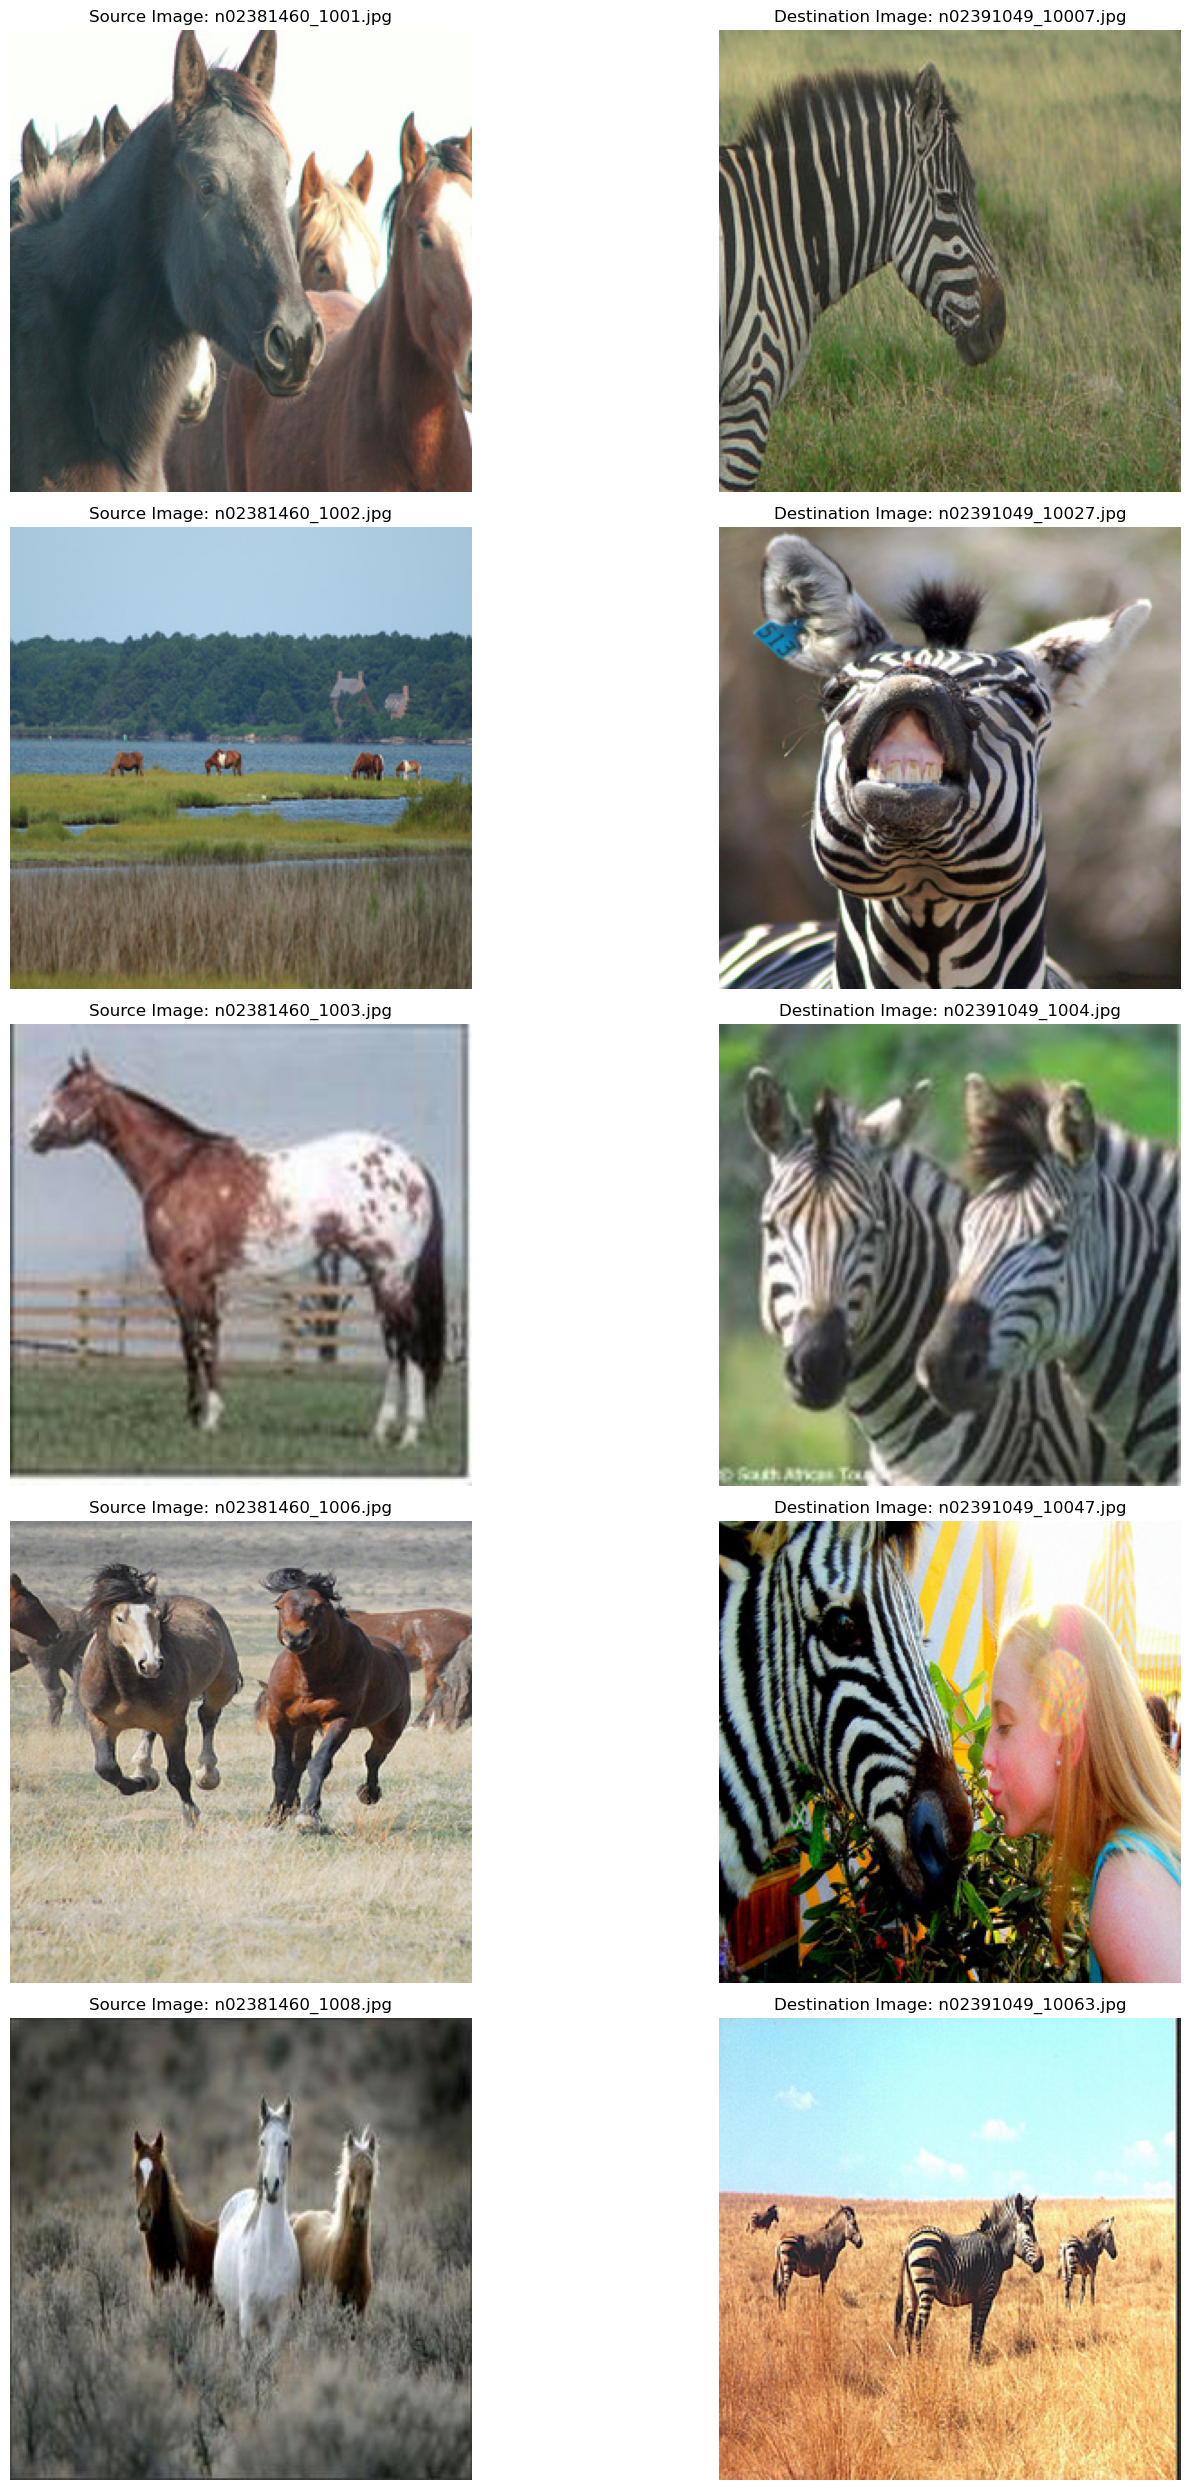

In [ ]:
import matplotlib.pyplot as plt

src_images_dir = r"e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\horse2zebra\trainA"
dst_images_dir = r"e:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\horse2zebra\trainB"

def load_image(file_path):
    try:
        with Image.open(file_path) as img:
            return np.array(img) / 255.0  
    except Exception as e:
        print(f"Cannot open image {file_path}: {e}")
        return None

#кол-во картинок для отображения
IMGS_CNT = 5

src_files = os.listdir(src_images_dir)[:IMGS_CNT]
dst_files = os.listdir(dst_images_dir)[:IMGS_CNT]

plt.figure(figsize=(17, 5 * IMGS_CNT))
for i in range(IMGS_CNT):

    src_img_path = os.path.join(src_images_dir, src_files[i])
    src_img = load_image(src_img_path)
    if src_img is not None:
        plt.subplot(IMGS_CNT, 2, 2 * i + 1)
        plt.imshow(src_img)
        plt.axis("off")
        plt.title(f"Source Image: {src_files[i]}")
    else:
        print(f"Skipping source image: {src_img_path}")

    dst_img_path = os.path.join(dst_images_dir, dst_files[i])
    dst_img = load_image(dst_img_path)
    if dst_img is not None:
        plt.subplot(IMGS_CNT, 2, 2 * i + 2)
        plt.imshow(dst_img)
        plt.axis("off")
        plt.title(f"Destination Image: {dst_files[i]}")
    else:
        print(f"Skipping destination image: {dst_img_path}")

plt.tight_layout()
plt.show()




In [ ]:
# # %%capture --no-stdout
# # , , --no-display and --output
#import matplotlib.pyplot as plt
#import numpy as np
#IMGS_CNT = 5
#plt.figure(figsize=(17,5*IMGS_CNT))
#for i, idx in enumerate(np.random.choice(np.arange(len(dataset)), size=IMGS_CNT, replace=False)):
#    data = dataset[idx]
#    img1, img2 = [(1+data[x])/2 for x in ['src', 'dst']]
#    plt.subplot(IMGS_CNT, 2, 2*i+1)
#    plt.imshow(img1.permute(1,2,0).detach().cpu().numpy())
#    plt.subplot(IMGS_CNT, 2, 2*i+2)
#    plt.imshow(img2.permute(1,2,0).detach().cpu().numpy())

#Problems section

## Задача 1 (4/10). Построить ГАН.

>Здесь нужно обучить GAN до нормального качества, померить FID и запомнить для будущего сравнения.

> В принципе можно использовать тот код который уже есть в репозитории курса, но лучше написать свой.

> Ради интереса, ваш GAN тоже можно потестировать на маленьких датасетах

> **ГАН надо обучить генерить как зебр (`dst`), так и коней (`src`).**

In [ ]:

import torch.nn as nn

#генератор
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            #входное векторное пространство размером nz
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            #(ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            #(ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            #(ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            #(ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            #(nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

#дискриминатор
class Discriminator(nn.Module):
    def __init__(self, nc, ndf):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            #входная картинка (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #(ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            #(ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            #(ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            #(ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            #на выходе ожидаем скалярное значение вероятности
        )

    def forward(self, input):
        return self.main(input)


In [ ]:
nz = 100  #вектор шума(размер)
ngf = 64  #фичи генератора(размер)
ndf = 64  #фичи дискриминатора(размер)
nc = 3    #число каналов в картинке, по классике rgb


In [ ]:
from torch.utils.data import Dataset

#класс для загрузки картинок из директории
class SingleClassImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        #список всех файлов изображений в директории
        self.images = [os.path.join(root, file) for file in os.listdir(root) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        path = self.images[index]
        with open(path, 'rb') as f:
            img = Image.open(f).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img

#датасет с понями
horse_dataset = SingleClassImageFolder(root=os.path.join(args.dataroot, args.trainA), transform=transform)
horse_dataloader = DataLoader(horse_dataset, batch_size=args.batch_size, shuffle=True)

#датасет с зебрами
zebra_dataset = SingleClassImageFolder(root=os.path.join(args.dataroot, args.trainB), transform=transform)
zebra_dataloader = DataLoader(zebra_dataset, batch_size=args.batch_size, shuffle=True)


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() and args.cuda else "cpu")
print(f'Using device: {device}')


criterion = nn.BCELoss()

#экземпляры моделей
netG_horse = Generator(nz, ngf, nc).to(device)
netD_horse = Discriminator(nc, ndf).to(device)

netG_zebra = Generator(nz, ngf, nc).to(device)
netD_zebra = Discriminator(nc, ndf).to(device)

#оптимизаторы
optimizerD_horse = optim.Adam(netD_horse.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG_horse = optim.Adam(netG_horse.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizerD_zebra = optim.Adam(netD_zebra.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG_zebra = optim.Adam(netG_zebra.parameters(), lr=0.0002, betas=(0.5, 0.999))


Using device: cpu


In [ ]:
num_epochs = 25

for epoch in range(num_epochs):
    for i, data in enumerate(horse_dataloader, 0):
        #обновление D сети
        #обучение на наших картинках
        netD_horse.zero_grad()
        real_cpu = data.to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), 1.0, device=device)  

        output = netD_horse(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        #обучения на фейковых картинках
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake = netG_horse(noise)
        label.fill_(0.0)  

        output = netD_horse(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD_horse.step()


        #обновление G сети: 

        netG_horse.zero_grad()
        label.fill_(1.0)
        output = netD_horse(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG_horse.step()

        #статистика
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(horse_dataloader)}]\tLoss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\tD(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')


[0/25][0/67]	Loss_D: 1.3946	Loss_G: 3.7386	D(x): 0.4543	D(G(z)): 0.4389/0.0241
[0/25][50/67]	Loss_D: 1.3590	Loss_G: 12.3999	D(x): 0.8814	D(G(z)): 0.6953/0.0000
[1/25][0/67]	Loss_D: 0.1193	Loss_G: 7.0250	D(x): 0.9011	D(G(z)): 0.0018/0.0011
[1/25][50/67]	Loss_D: 0.3929	Loss_G: 4.0781	D(x): 0.8771	D(G(z)): 0.2034/0.0209
[2/25][0/67]	Loss_D: 0.7370	Loss_G: 3.4580	D(x): 0.5535	D(G(z)): 0.0149/0.0415
[2/25][50/67]	Loss_D: 0.7222	Loss_G: 5.5370	D(x): 0.9084	D(G(z)): 0.4054/0.0102
[3/25][0/67]	Loss_D: 0.3253	Loss_G: 2.0424	D(x): 0.8627	D(G(z)): 0.1462/0.1453
[3/25][50/67]	Loss_D: 0.4822	Loss_G: 4.2599	D(x): 0.9286	D(G(z)): 0.3082/0.0176
[4/25][0/67]	Loss_D: 0.6852	Loss_G: 3.7085	D(x): 0.6483	D(G(z)): 0.1605/0.0327
[4/25][50/67]	Loss_D: 0.8733	Loss_G: 2.2751	D(x): 0.6882	D(G(z)): 0.2243/0.1289
[5/25][0/67]	Loss_D: 0.5747	Loss_G: 3.1248	D(x): 0.7650	D(G(z)): 0.1895/0.0566
[5/25][50/67]	Loss_D: 0.5301	Loss_G: 3.8759	D(x): 0.8193	D(G(z)): 0.2364/0.0285
[6/25][0/67]	Loss_D: 0.5388	Loss_G: 3.3609	D(

In [ ]:
from pytorch_fid import fid_score

#генерация семплов для оценки
def generate_samples(generator, num_samples, nz):
    generator.eval()
    samples = []
    with torch.no_grad():
        for _ in range(num_samples // args.batch_size):
            noise = torch.randn(args.batch_size, nz, 1, 1, device=device)
            fake_images = generator(noise)
            samples.append(fake_images.cpu())
    generator.train()
    return torch.cat(samples, dim=0)

#генерация пони
num_samples = 1000
fake_horse_images = generate_samples(netG_horse, num_samples, nz)
#сохраняем картинки для подсчета FID
fake_horse_dir = 'fake_horse_images'
os.makedirs(fake_horse_dir, exist_ok=True)
for idx, img in enumerate(fake_horse_images):
    vutils.save_image(img, f'{fake_horse_dir}/img_{idx}.png', normalize=True)

real_horse_dir = os.path.join(args.dataroot, args.trainA)

#FID для поняшек
fid_value_horse = fid_score.calculate_fid_given_paths([real_horse_dir, fake_horse_dir], batch_size=args.batch_size, device=device, dims=2048)
print(f'FID for horse images: {fid_value_horse}')

#тоже самое, только для ззебр
fake_zebra_images = generate_samples(netG_zebra, num_samples, nz)
fake_zebra_dir = 'fake_zebra_images'
os.makedirs(fake_zebra_dir, exist_ok=True)
for idx, img in enumerate(fake_zebra_images):
    vutils.save_image(img, f'{fake_zebra_dir}/img_{idx}.png', normalize=True)

real_zebra_dir = os.path.join(args.dataroot, args.trainB)

fid_value_zebra = fid_score.calculate_fid_given_paths([real_zebra_dir, fake_zebra_dir], batch_size=args.batch_size, device=device, dims=2048)
print(f'FID for zebra images: {fid_value_zebra}')


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\Никита/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:03<00:00, 24.7MB/s]
100%|██████████| 62/62 [00:19<00:00,  3.23it/s]


FID for horse images: 249.04217374490503


100%|██████████| 62/62 [00:19<00:00,  3.18it/s]


FID for zebra images: 425.4138080161962


## Задача 2 (6/10). Построить Cycle GAN.

> Используя ГАНы из Задачи 1, надо построить CycleGAN ([статья](https://arxiv.org/pdf/1703.10593)), обучить его до сравнимого с отдельными ГАНами качества, померить FID и запомнить для будущего сравнения.

In [ ]:
# генератор

class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super(ResnetBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),

            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.conv_block(x)

class ResnetGenerator(nn.Module):
    def __init__(self, input_nc, output_nc, ngf=64, n_blocks=9):
        super(ResnetGenerator, self).__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, ngf, kernel_size=7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(True),
        ]

        n_downsampling = 2
        for i in range(n_downsampling):
            mult = 2**i
            model += [
                nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(ngf * mult * 2),
                nn.ReLU(True),
            ]

        mult = 2**n_downsampling
        for i in range(n_blocks):
            model += [ResnetBlock(ngf * mult)]

        for i in range(n_downsampling):
            mult = 2**(n_downsampling - i)
            model += [
                nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2),
                                   kernel_size=3, stride=2,
                                   padding=1, output_padding=1),
                nn.InstanceNorm2d(int(ngf * mult / 2)),
                nn.ReLU(True),
            ]
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, output_nc, kernel_size=7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*model)

    def forward(self, input):
        return self.model(input)


In [20]:
# дискриминатор
class NLayerDiscriminator(nn.Module):
    def __init__(self, input_nc, ndf=64, n_layers=3):
        super(NLayerDiscriminator, self).__init__()
        sequence = [
            nn.Conv2d(input_nc, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),
        ]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult,
                          kernel_size=4, stride=2, padding=1),
                nn.InstanceNorm2d(ndf * nf_mult),
                nn.LeakyReLU(0.2, True),
            ]
        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult,
                      kernel_size=4, stride=1, padding=1),
            nn.InstanceNorm2d(ndf * nf_mult),
            nn.LeakyReLU(0.2, True),
        ]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=4, stride=1, padding=1)]
        self.model = nn.Sequential(*sequence)

    def forward(self, input):
        return self.model(input)


In [ ]:
#гиперпараметры
input_nc = 3  #число каналов входной картинки
output_nc = 3  #число каналов на выходе картинки

#экземпляры генераторов и дискриминаторов
G_AB = ResnetGenerator(input_nc, output_nc).to(device)
G_BA = ResnetGenerator(input_nc, output_nc).to(device)
D_A = NLayerDiscriminator(input_nc).to(device)
D_B = NLayerDiscriminator(input_nc).to(device)

#функции потерь
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()


# оптимизаторы
lr = 0.0002
beta1 = 0.5
beta2 = 0.999

optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()),
                               lr=lr, betas=(beta1, beta2))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(beta1, beta2))

In [ ]:

real_label = 1.0
fake_label = 0.0

Tensor = torch.cuda.FloatTensor if torch.cuda.is_available() else torch.Tensor

num_epochs = 25

for epoch in range(num_epochs):
    for i, (data_A, data_B) in enumerate(zip(horse_dataloader, zebra_dataloader)):
        #реальные картинки из обоих доменов
        real_A = data_A.to(device)
        real_B = data_B.to(device)
        batch_size = real_A.size(0)

        #генерим фейковые картинки
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)

        #обновляем дискриминатор D_A 
        optimizer_D_A.zero_grad()

        #предикт для реальных и фейковых картинок
        pred_real_A = D_A(real_A)
        pred_fake_A = D_A(fake_A.detach())

        #тензоры меток
        valid = torch.ones_like(pred_real_A, device=device)
        fake = torch.zeros_like(pred_fake_A, device=device)

        #тензоры меток дискриминатора D_A
        loss_D_real = criterion_GAN(pred_real_A, valid)
        loss_D_fake = criterion_GAN(pred_fake_A, fake)
        loss_D_A = (loss_D_real + loss_D_fake) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        #обновляем дискриминатор D_B 
        optimizer_D_B.zero_grad()

        #предикт для реальных и фейковых картинок
        pred_real_B = D_B(real_B)
        pred_fake_B = D_B(fake_B.detach())

        #тензоры меток
        valid = torch.ones_like(pred_real_B, device=device)
        fake = torch.zeros_like(pred_fake_B, device=device)

        #тензоры меток дискриминатора D_B
        loss_D_real = criterion_GAN(pred_real_B, valid)
        loss_D_fake = criterion_GAN(pred_fake_B, fake)
        loss_D_B = (loss_D_real + loss_D_fake) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

        #обновляем генераторы 
        optimizer_G.zero_grad()

        #потери
        loss_identity_A = criterion_identity(G_BA(real_A), real_A) * 5.0
        loss_identity_B = criterion_identity(G_AB(real_B), real_B) * 5.0

  
        pred_fake_A = D_A(fake_A)
        pred_fake_B = D_B(fake_B)
        valid_A = torch.ones_like(pred_fake_A, device=device)
        valid_B = torch.ones_like(pred_fake_B, device=device)
        loss_GAN_BA = criterion_GAN(pred_fake_A, valid_A)
        loss_GAN_AB = criterion_GAN(pred_fake_B, valid_B)

  
        recovered_A = G_BA(fake_B)
        recovered_B = G_AB(fake_A)
        loss_cycle_A = criterion_cycle(recovered_A, real_A) * 10.0
        loss_cycle_B = criterion_cycle(recovered_B, real_B) * 10.0

        #общая потеря генераторов
        loss_G = loss_identity_A + loss_identity_B + loss_GAN_AB + loss_GAN_BA + loss_cycle_A + loss_cycle_B
        loss_G.backward()
        optimizer_G.step()

        #статистика
        if i % 50 == 0:
            print(f'Epoch [{epoch}/{num_epochs}] Batch [{i}/{min(len(horse_dataloader), len(zebra_dataloader))}] '
                  f'Loss_D_A: {loss_D_A.item():.4f} Loss_D_B: {loss_D_B.item():.4f} '
                  f'Loss_G: {loss_G.item():.4f}')



#сохранение моделей
torch.save(G_AB.state_dict(), f'G_AB_epoch_{epoch}.pth')
torch.save(G_BA.state_dict(), f'G_BA_epoch_{epoch}.pth')
torch.save(D_A.state_dict(), f'D_A_epoch_{epoch}.pth')
torch.save(D_B.state_dict(), f'D_B_epoch_{epoch}.pth')


Epoch [0/25] Batch [0/67] Loss_D_A: 0.6640 Loss_D_B: 0.5895 Loss_G: 13.7022
Epoch [0/25] Batch [50/67] Loss_D_A: 0.2181 Loss_D_B: 0.2527 Loss_G: 9.1938
Epoch [1/25] Batch [0/67] Loss_D_A: 0.1973 Loss_D_B: 0.2034 Loss_G: 8.7231
Epoch [1/25] Batch [50/67] Loss_D_A: 0.3014 Loss_D_B: 0.2067 Loss_G: 7.9705
Epoch [2/25] Batch [0/67] Loss_D_A: 0.1968 Loss_D_B: 0.2289 Loss_G: 9.3649
Epoch [2/25] Batch [50/67] Loss_D_A: 0.2478 Loss_D_B: 0.1979 Loss_G: 8.2528
Epoch [3/25] Batch [0/67] Loss_D_A: 0.2188 Loss_D_B: 0.2476 Loss_G: 7.5098
Epoch [3/25] Batch [50/67] Loss_D_A: 0.2430 Loss_D_B: 0.2162 Loss_G: 6.7035
Epoch [4/25] Batch [0/67] Loss_D_A: 0.1649 Loss_D_B: 0.1721 Loss_G: 7.1377
Epoch [4/25] Batch [50/67] Loss_D_A: 0.1794 Loss_D_B: 0.2141 Loss_G: 7.4467
Epoch [5/25] Batch [0/67] Loss_D_A: 0.1567 Loss_D_B: 0.1917 Loss_G: 7.1026
Epoch [5/25] Batch [50/67] Loss_D_A: 0.1924 Loss_D_B: 0.2067 Loss_G: 7.0980
Epoch [6/25] Batch [0/67] Loss_D_A: 0.1845 Loss_D_B: 0.1936 Loss_G: 6.7130
Epoch [6/25] Batch

In [ ]:
#генерируем картинки
def generate_images(generator, dataloader, num_images=1000):
    generator.eval()
    images = []
    with torch.no_grad():
        for i, data in enumerate(dataloader):
            real_image = data.to(device)
            fake_image = generator(real_image)
            images.append(fake_image.cpu())
            if len(images) * real_image.size(0) >= num_images:
                break
    generator.train()
    return torch.cat(images, dim=0)

#генерируем картинки из домена A в B
fake_B_images = generate_images(G_AB, horse_dataloader, num_images=1000)
#генерируем картинки из домена B в A
fake_A_images = generate_images(G_BA, zebra_dataloader, num_images=1000)


def save_images(images, folder):
    os.makedirs(folder, exist_ok=True)
    for idx, img in enumerate(images):
        vutils.save_image(img, os.path.join(folder, f'img_{idx}.png'), normalize=True)

# сохраняем изображения
save_images(fake_B_images, 'fake_B_images')
save_images(fake_A_images, 'fake_A_images')




real_B_dir = os.path.join(args.dataroot, args.trainB)
real_A_dir = os.path.join(args.dataroot, args.trainA)

#FID для домена B (реальные B и сгенерированные из A)
fid_value_B = fid_score.calculate_fid_given_paths([real_B_dir, 'fake_B_images'], batch_size=args.batch_size, device=device, dims=2048)
print(f'FID for domain B images: {fid_value_B}')

#FID для домена A (реальные A и сгенерированные из B)
fid_value_A = fid_score.calculate_fid_given_paths([real_A_dir, 'fake_A_images'], batch_size=args.batch_size, device=device, dims=2048)
print(f'FID for domain A images: {fid_value_A}')


100%|██████████| 63/63 [00:19<00:00,  3.26it/s]


FID for domain B images: 297.1040464188155


100%|██████████| 63/63 [00:19<00:00,  3.25it/s]


FID for domain A images: 192.2639059391858


## Задача 3 (1/10). Анализ.

> Проанализируйте результаты полученные моделями.

> Покажите хорошие и плохие примеры моделей. Чем можно объяснить подобное поведение моделей? Подчеркните проблемы предложенной модели, которые вы заметили, и возможные решения.

> Покажите самый смешной результат генерации, который у вас получался.

Для лошадей наш FID составил 192.2639059391858. Это довольно высокое значение FID, указывающее на то, что сгенерированные изображения значительно отличаются от реальных изображений из домена A. В идеале, FID должен быть как можно ниже, что соответствует большей схожести между распределениями реальных и сгенерированных изображений.

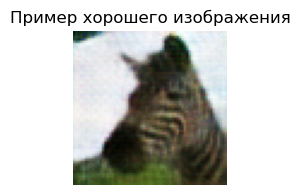

In [29]:

image_path = r'E:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\fake_A_images\img_597.png'

image = Image.open(image_path)
plt.figure(figsize=(2, 2)) 
plt.imshow(image)
plt.axis('off')  
plt.title('Пример хорошего изображения')
plt.show()

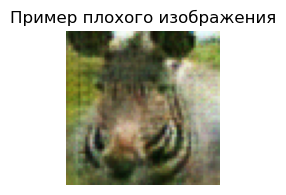

In [32]:
image_path = r'E:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\fake_A_images\img_63.png'

image = Image.open(image_path)
plt.figure(figsize=(2, 2)) 
plt.imshow(image)
plt.axis('off')  
plt.title('Пример плохого изображения')
plt.show()

На хорошем примере видно, что Зебра получилась четкой, видно небо, траву и саму зебру. В то время, как на плохом примере мы видим полу-зебру полу-кабана... В целом в среднем посмотрев на картинки можно сделать следующие выводы: В некоторых случаях модель могла успешно перенести общую форму и позу животного, сохранив контуры и основные черты исходного изображения. Модель смогла правильно изменять цветовую палитру изображения, например, превращая коричневую шерсть лошади в полосатую окраску зебры. В то же время в некоторых сгенерированных изображениях могли появляться артефакты, искажения или шум, особенно в областях с мелкими деталями. Иногда модель могла терять важные детали исходного изображения, приводя к размытым или неузнаваемым объектам. Модель могла неудачно переносить особенности из одного домена в другой, создавая нереалистичные изображения (например, лошадь с частичными полосами или зебра с некорректной окраской, или полу-зебра полу-кабан 

Данные причины можно объяснить следующим:

Было мало эпох: Возможно, 25 эпох недостаточно для полного обучения CycleGAN на данном датасете. CycleGAN обычно требует большего количества эпох для достижения хороших результатов, однако из-за ограничений в железе пришлось воспользоваться минимимальным количеством эпох, которые позволяли модели выдавать хоть какой-то результат, поэтому для улучшения нужно увеличить количество эпох.

Сходимость: GAN-ы могут быть нестабильными при обучении, и могут не сходиться к оптимальному решению за короткое время.

Архитектура: возможны проблемы в самой архитектуре модели, например, некоторые фичи могли не захватываться моделью, что стало причиной возникновения каких-либо артифактов и т.п.

Гиперпараметры: возможно выбранные гиперпараметры были не самыми оптимальными, стоит поиграться с ними.

Низкое качество изображений для обучения: 256х256 пикселей хоть и является стандартом для модели CycleGAN, но все равно понятно, что чем выше качество изображения, тем лучше качество генерации, но это, несомненно, стоит вычислительных мощностей.

Дисбаланс данных: для обучения у нас было 1334 картинки с зебрами, а с лошадьми всего 1067 картинок, стоит сделать эту дельту в разы меньше.

Я бы предложил следующий алгоритм улучшения качества изображений:

Во-первых, увеличил количество эпох, например, с 25 до 50 и посмотрел бы как изменился бы FID. Если он сильно уменьшиться, то стоит капать в это направление. 

Во-вторых, если FID уменьшился бы очень сильно, то можно аккуратно поиграться с архитектурой и гиперпараметрами. Если же после изменения количества эпох FID не сильно изменился, то тут уже явно стоит пересмотреть архитектуру и гиперпараметры.
Например, добавить больше Residual блоков или же изменить скорость обучения(lr), или поиграться с бета-параметрами оптимизатора градиента Adam
В-третьих, я бы все-таки изменил дельту в количество изображений для обучения, это можно сделать с помощью аугментации данных

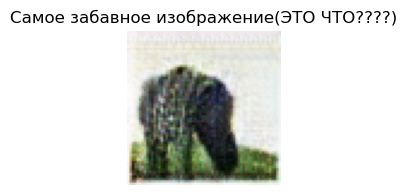

In [39]:
image_path = r'E:\HSE\ФКН\Генеративные модели\HW2\#cyclegan\fake_B_images\img_629.png'

image = Image.open(image_path)
plt.figure(figsize=(2, 2)) 
plt.imshow(image)
plt.axis('off')  
plt.title('Самое забавное изображение(ЭТО ЧТО????)')
plt.show()